In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
base_path = "/content/drive/MyDrive/Instacart Dashboard/Dataset/"

**Aisles: Data Cleaning & EDA**

In [ ]:
aisles = pd.read_csv(base_path + "aisles.csv")

In [ ]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [ ]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
aisles.isnull().sum()

,0
aisle_id,0
aisle,0


In [ ]:
aisles.duplicated().sum()

np.int64(0)

In [ ]:
print("Total Aisles:", aisles['aisle_id'].nunique())

Total Aisles: 134


In [29]:
save_path = "/content/drive/MyDrive/Instacart Dashboard/Python EDA/Cleaned Dataset/"

In [30]:
import os
os.makedirs(save_path, exist_ok=True)

aisles.to_csv(save_path + "aisles_cleaned.csv", index=False)

**Departments: Data Cleaning & EDA**

In [31]:
departments = pd.read_csv(base_path + "departments.csv")

In [32]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [33]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [34]:
departments.isnull().sum()

,0
department_id,0
department,0


In [35]:
departments.duplicated().sum()

np.int64(0)

In [36]:
print("Total Departments:", departments['department_id'].nunique())

Total Departments: 21


In [37]:
departments.to_csv(save_path + "departments_cleaned.csv", index=False)

**Order Products: Data Cleaning & EDA**

In [38]:
order_products = pd.read_csv(base_path + "order_products__prior.csv")

In [39]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [40]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


In [41]:
order_products.isnull().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0


In [42]:
order_products.duplicated().sum()

np.int64(0)

In [43]:
print("Unique Orders:", order_products['order_id'].nunique())

Unique Orders: 3214874


In [44]:
print("Unique Products:", order_products['product_id'].nunique())

Unique Products: 49677


In [45]:
order_products['reordered'].value_counts()

,count
reordered,
1,19126536
0,13307953


In [46]:
reorder_rate = ( order_products['reordered'].mean() * 100)
print(f"Reorder Rate: {reorder_rate:.2f}%")

Reorder Rate: 58.97%


In [52]:
basket_size = (order_products.groupby('order_id')['product_id'].count())

In [54]:
order_products.to_csv(save_path + "order_products_prior_cleaned.csv", index=False)

**Orders: Data Cleaning & EDA**

In [55]:
orders = pd.read_csv(base_path + "orders.csv")

In [56]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [57]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [58]:
orders.isnull().sum()

,0
order_id,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,206209


In [59]:
orders.duplicated().sum()

np.int64(0)

In [61]:
print("Total Customers:", orders['user_id'].nunique())

Total Customers: 206209


In [62]:
print("Total Orders:", orders['order_id'].nunique())

Total Orders: 3421083


In [64]:
orders_per_customer = (orders.groupby('user_id')['order_number'].max())
orders_per_customer

,order_number
user_id,
1,11
2,15
3,13
4,6
5,5
...,...
206205,4
206206,68
206207,17


In [65]:
customer_segments = (
    orders.groupby('user_id')['order_number']
    .max()
    .reset_index()
)

customer_segments.rename(
    columns={'order_number':'total_orders'},
    inplace=True
)

In [66]:
import numpy as np

customer_segments['segment'] = np.select(
    [
        customer_segments['total_orders'] >= 20,
        customer_segments['total_orders'] >= 10
    ],
    [
        'Loyal',
        'Regular'
    ],
    default='Occasional'
)

In [67]:
customer_segments['segment'].value_counts()

,count
segment,
Occasional,95481
Regular,56797
Loyal,53931


In [68]:
orders.to_csv(save_path + "orders_cleaned.csv", index=False)

In [69]:
customer_segments.to_csv(save_path + "customer_segments.csv", index=False)

Visualization

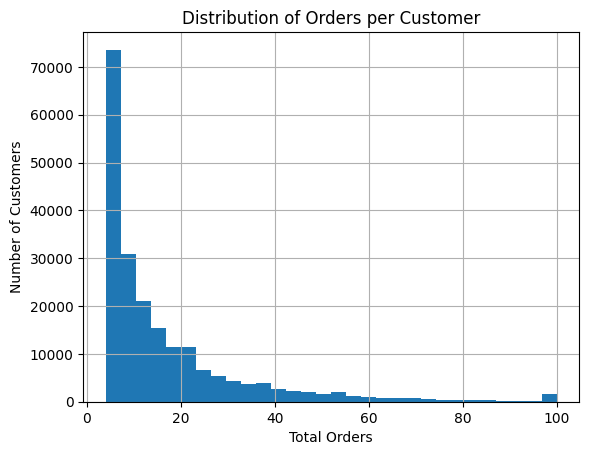

In [70]:
orders_per_customer.hist(bins=30)
plt.title('Distribution of Orders per Customer')
plt.xlabel('Total Orders')
plt.ylabel('Number of Customers')
plt.show()

**Products: Data Cleaning & EDA**

In [71]:
products = pd.read_csv(base_path + "products.csv")

In [72]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [73]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [74]:
products.isnull().sum()

,0
product_id,0
product_name,0
aisle_id,0
department_id,0


In [75]:
products.duplicated().sum()

np.int64(0)

In [76]:
products['department_id'].value_counts().head(10)

,count
department_id,
11,6563
19,6264
13,5371
7,4365
1,4007
16,3449
17,3085
15,2092
9,1858


In [77]:
products['aisle_id'].value_counts().head(10)

,count
aisle_id,
100,1258
45,1246
37,1091
47,1038
120,1026
107,989
94,894
21,891
38,880


In [78]:
products.to_csv(save_path + "products_cleaned.csv", index=False)